In [11]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob

from monai.transforms import (
    Compose, LoadImageD, EnsureChannelFirstD, ScaleIntensityRangeD,
    EnsureTypeD, LambdaD, RandSpatialCropSamplesD
)
from monai.data import Dataset, DataLoader

import albumentations as A

from monai.transforms import MapTransform   
from PIL import Image


In [12]:
UAVID_CLS = [
    'Background clutter', # 0
    'Building',           # 1
    'Road',               # 2
    'Tree',               # 3
    'Low vegetation',     # 4
    'Moving car',         # 5
    'Static car',         # 6
    'Human',              # 7
]

UAVID_COLORMAP = [
    (0, 0, 0),          # Background Clutter
    (128, 0, 0),        # Building
    (128, 64, 128),     # Road
    (0, 128, 0),        # Tree
    (128, 128, 0),      # Low vegetation
    (64, 0, 128),       # Moving car
    (192, 0, 192),      # Static car
    (64, 64, 0),        # Human 
]

COLOR2ID = {rgb: idx for idx, rgb in enumerate(UAVID_COLORMAP)}
ID2COLOR = {idx: rgb for idx, rgb in enumerate(UAVID_COLORMAP)}

def rgb_to_cls(mask):
    # Mask shape: (3, H, W)
    _, h, w = mask.shape
    mapped_mask = np.zeros((h, w), dtype=np.uint8)

    for rgb, cls_id in COLOR2ID.items():
        matches = np.all(mask == np.array(rgb)[:, None, None], axis=0)
        mapped_mask[matches] = cls_id

    return mapped_mask[np.newaxis, ...].astype(np.int64)  # add channel dimension

In [13]:
import numpy as np
from monai.transforms import MapTransform   

class AlbumentationsD(MapTransform):
    def __init__(self, keys, aug):
        super().__init__(keys)
        self.aug = aug
    
    def __call__(self, data):
        d = dict(data)
        img = d[self.keys[0]]
        img = np.asarray(img)
        img = np.transpose(img, (1, 2, 0))  # C,H,W -> H,W,C

        if len(self.keys) == 1:
            augmented = self.aug(image=img)
            img_aug = augmented['image']
            img_aug = np.transpose(img_aug, (2, 0, 1))  # [C,H,W]
            d[self.keys[0]] = img_aug.astype(np.float32)
            return d

        mask = d[self.keys[1]]
        mask = np.asarray(mask)

        mask = np.transpose(mask, (1, 2, 0))  # C,H,W -> H,W,C

        augmented = self.aug(image=img, mask=mask)
        img_aug = augmented['image']
        mask_aug = augmented['mask']

        img_aug = np.transpose(img_aug, (2, 0, 1))  # [C,H,W]
        mask_aug = np.transpose(mask_aug, (2, 0, 1))  # [C,H,W] RGB mask

        d[self.keys[0]] = img_aug.astype(np.float32)   # image
        d[self.keys[1]] = mask_aug.astype(np.uint8)    # label (RGB)

        return d

In [14]:
import albumentations as A

def get_weather_transforms(
    rain=False,
    sunny=False,
    snow=False,
    foggy=False,
    clahe=False,
    copy_paste=None,
):
    Aug = []

    if copy_paste:
        Aug.append(copy_paste)

    if clahe:
        Aug.append(
            A.CLAHE(clip_limit=4.0, tile_grid_size=(8,8), p=0.5)
        )

    Aug.extend([
        A.HorizontalFlip(p=0.5),
        A.Affine(
            translate_percent=0.05,
            scale=(0.9, 1.1),
            rotate=10,
            p=0.0,
        ),
        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.2),
        A.RandomGamma(gamma_limit=(80, 120), p=0.0),
        A.GaussianBlur(blur_limit=(3,5), p=0.0),
        A.GaussNoise(std_range=(0.05, 0.1), p=0.0),
        A.VerticalFlip(p=0.0),
        A.RandomRotate90(p=0.0),
    ])



    W = []
    if rain:
        W.append(
            A.RandomRain(
                slant_range=(-10, 10),
                drop_length=15,
                drop_width=1,
                drop_color=(200, 200, 200),
                blur_value=12,
                brightness_coefficient=0.52,
                rain_type='heavy',
                p=0.25,
            )
        )
    
    if sunny:
        W.append(
            A.RandomSunFlare(
                flare_roi=(0, 0, 1, 1),
                angle_range=(0, 1),
                num_flare_circles_range=(4, 8),
                src_radius=100,
                src_color=(255, 255, 255),
                p=0.25,
            )
        )

    if snow:
        W.append(
            A.RandomSnow(
                snow_point_range=(0.1, 0.3),
                brightness_coeff=2.5,
                p=0.25,
            )
        )

    if foggy:
        W.append(
            A.RandomFog(
                fog_coef_range=(0.3, 0.4),
                alpha_coef=0.1,
                p=0.01,
            )
        )

    Aug.extend(W)
    Aug.append(A.Normalize(p=1.0))
    return A.Compose(Aug)

def get_val_transforms():
    return A.Compose([
        A.Normalize(p=1.0),
    ])

In [15]:
keys = ['image', 'label']
patch_size = 512
transform = Compose([
    LoadImageD(keys=keys),
    EnsureChannelFirstD(keys=keys),
    RandSpatialCropSamplesD(
        keys=keys,
        roi_size=[patch_size, patch_size],
        num_samples=6,
        random_size=False,
    ),
    LambdaD(keys=['label'], func=rgb_to_cls),
    EnsureTypeD(keys=keys),
])

In [16]:
ROOT = Path(os.getcwd()).parent
DATA_ROOT = ROOT / "data" / "UAVid" / "uavid_train" 

images = sorted(glob(str(DATA_ROOT / "seq*" / "Images" / "*.png")))
labels = sorted(glob(str(DATA_ROOT / "seq*" / "Labels" / "*.png")))

data = [{"image": img, "label": lbl} for img, lbl in zip(images, labels)]

dataset = Dataset(data=data, transform=transform)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

Image batch shape: torch.Size([12, 3, 512, 512])
Label batch shape: torch.Size([12, 1, 512, 512])
Image pixel value range: 0.0 to 255.0


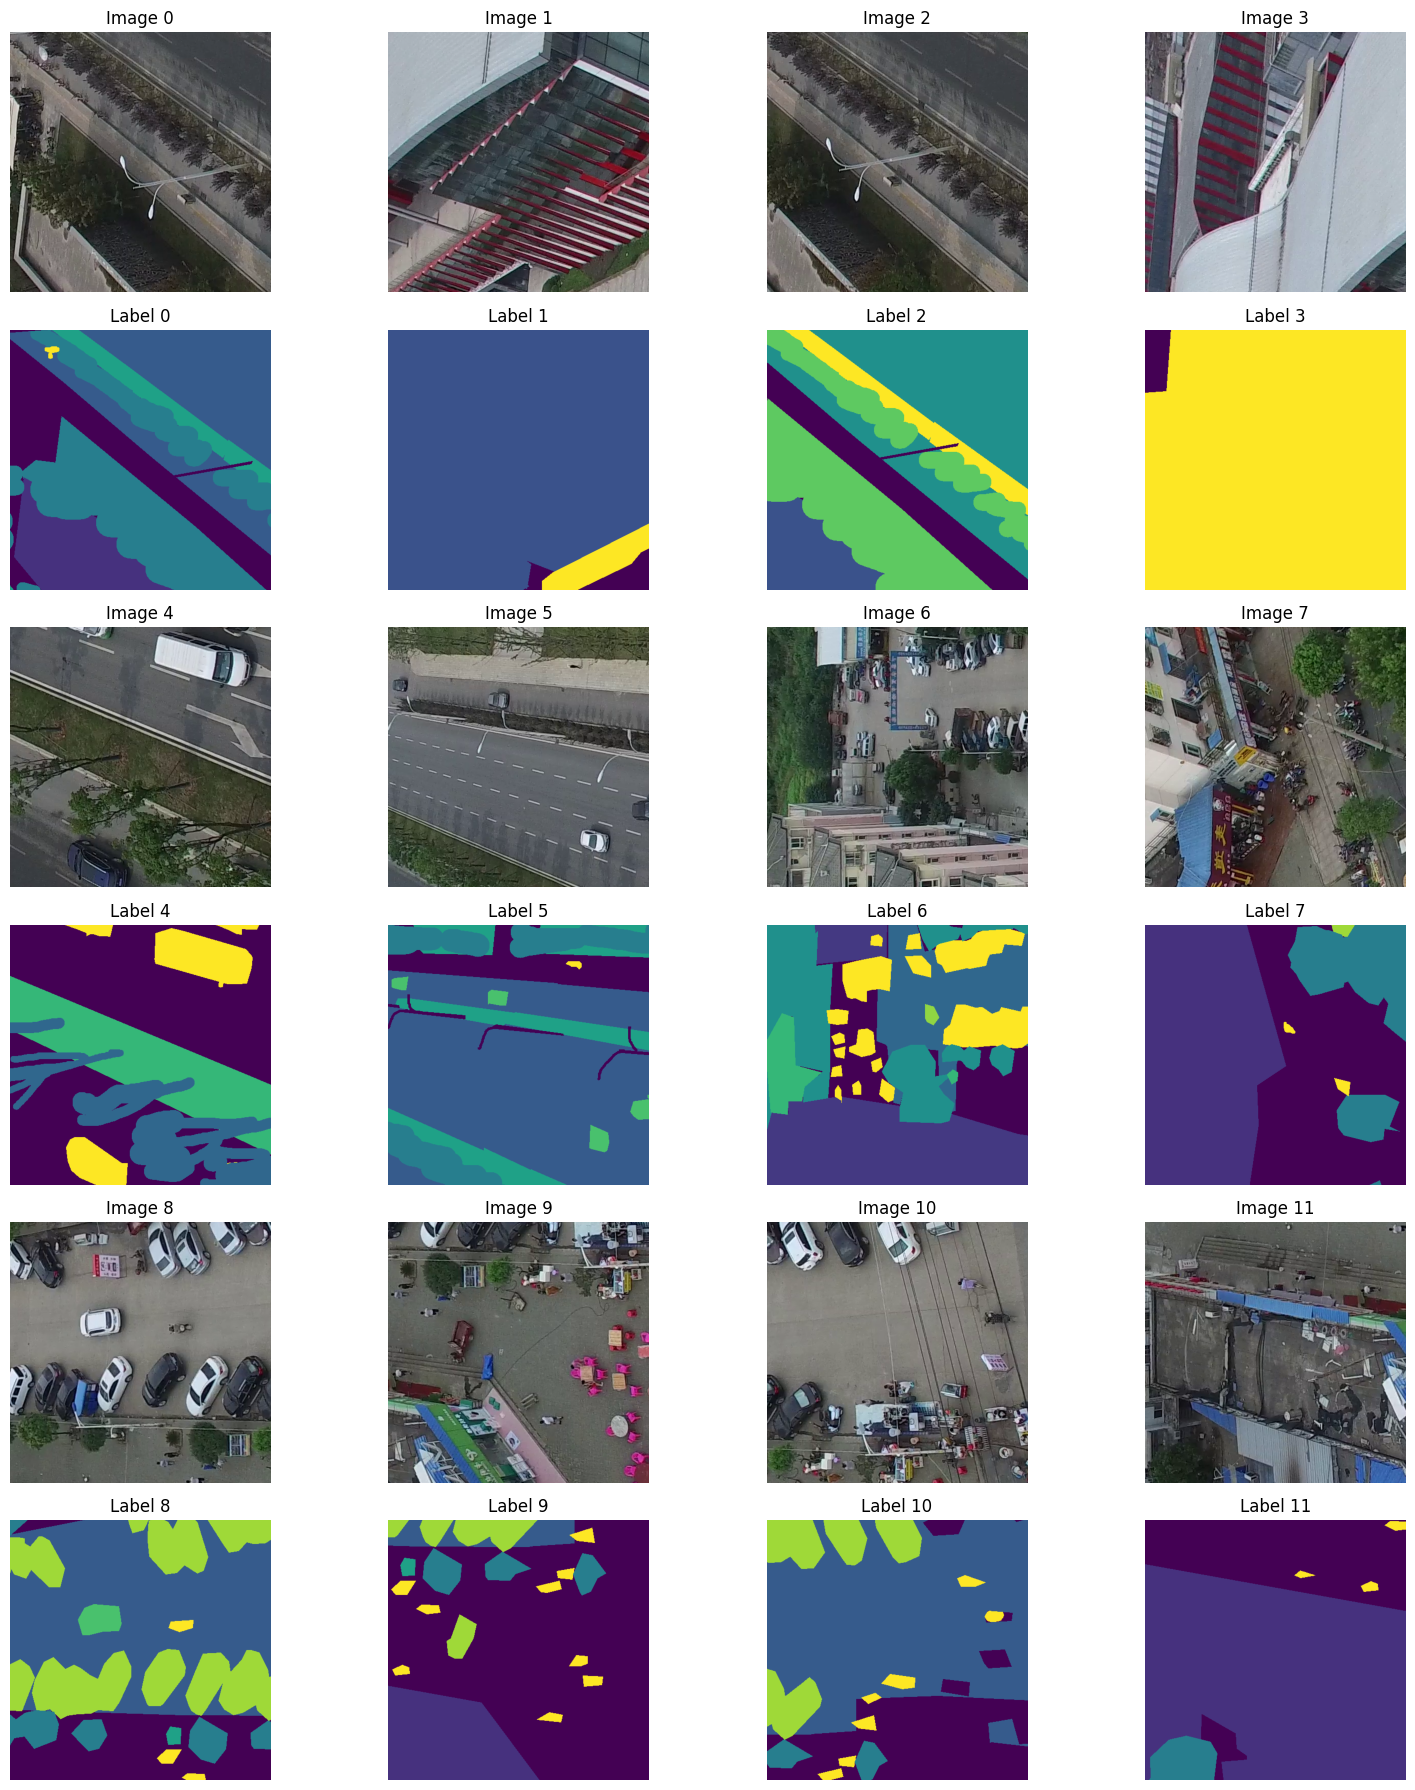

In [17]:
batch = next(iter(loader))

imgs = batch["image"]
lbls = batch["label"]

print("Image batch shape:", imgs.shape)
print("Label batch shape:", lbls.shape)
print("Image pixel value range:", imgs.min().item(), "to", imgs.max().item())

def chw_to_hwc(x):
    return np.transpose(x, (1, 2, 0))

def normalize_0_1(arr):
    arr = arr.astype(np.float32)
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn)

num_samples = imgs.shape[0]
cols = 4
rows = int(np.ceil(num_samples / cols))
rows *= 2

plt.figure(figsize=(4 * cols, 3 * rows))

for i in range(num_samples):
    r = i // cols
    c = i % cols

    img_np = imgs[i].numpy()
    img_norm = normalize_0_1(img_np)       # CHW in [0,1]
    img_hwc = chw_to_hwc(img_norm)

    plt.subplot(rows, cols, r * 2 * cols + c + 1)
    plt.imshow(img_hwc)
    plt.axis("off")
    plt.title(f"Image {i}")

    lbl_np = lbls[i].numpy()
    lbl_2d = lbl_np[0] if lbl_np.shape[0] == 1 else lbl_np  # [H,W]

    plt.subplot(rows, cols, r * 2 * cols + cols + c + 1)
    plt.imshow(lbl_2d)
    plt.axis("off")
    plt.title(f"Label {i}")

plt.tight_layout()
plt.show()